In [1]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display, Image
import os

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'STIXGeneral'

def show(fig, name):
    path = f'/tmp/{name}'
    fig.savefig(path, bbox_inches='tight', dpi=150)
    plt.close(fig)
    display(Image(path))

BASE         = '/capstor/scratch/cscs/framunno'
METRICS_BASE = '/users/framunno/res_iono'
DYN_ACT      = [('high', 'high'), ('high', 'low'), ('low', 'high'), ('low', 'low')]
COMBO_LABELS = [f'{d}/{a}' for d, a in DYN_ACT]   # etichette compatte per gli assi x

MODEL_DIRS = {
    'CLASSIC': BASE + '/results_diffusion_classic_singlepass_step200k_dyn{dyn}_act{act}',
    'NOCOND':  BASE + '/results_diffusion_nocond_singlepass_step200k_dyn{dyn}_act{act}',
    'UNET':    BASE + '/results_unet_singlepass_step200k_dyn{dyn}_act{act}',
}

COND_FRAMES = 15
FRAME_DT    = 2
NORM_SCALE  = 80000

MODEL_ORDER  = ['CLASSIC', 'NOCOND', 'UNET', 'PERSISTENCE']
MODEL_COLORS = {'CLASSIC': '#2a78d6', 'NOCOND': '#eb6834', 'UNET': '#1baf7a', 'PERSISTENCE': '#7a7a76'}

# Analisi metriche singlepass (v3)

Confronto CLASSIC / NOCOND / UNET (+ baseline PERSISTENCE) sulle 4 combinazioni dynamics x activity,
usando le metriche calcolate da `compute_metrics_v3.py` (NRMSE di mean/std/cpcp + PS log-MSE/LPIPS/SSIM).
Stesso stile di `explore_2015_timeseries.ipynb`: colori validati, error bar tra i sample (non tra i frame),
legenda fuori dal plot, tabelle colorate per finestra (qui: `frame_idx` all'interno della sequenza corta,
non ore — le sequenze singlepass sono gia' brevi, 7 frame predetti).

In fondo: generazione GIF/MP4 opzionale per ispezionare visivamente una sequenza.

In [2]:
# =============================================================================
# Carica i CSV gia' calcolati da compute_metrics_v3.py (nessun GPU necessario qui)
# =============================================================================
def load_combo_csv(fname):
    dfs = []
    for dyn, act in DYN_ACT:
        path = f'{METRICS_BASE}/metrics_v3_singlepass_dyn{dyn}_act{act}/{fname}'
        d = pd.read_csv(path)
        d['model'] = d['model'].str.upper()   # CSV ha 'classic'/'nocond'/'unet' minuscolo (da --labels dello sbatch)
        d['dyn'] = dyn
        d['act'] = act
        d['combo'] = f'{dyn}/{act}'
        dfs.append(d)
    return pd.concat(dfs, ignore_index=True)

bar_overall_df    = load_combo_csv('bar_metrics_overall_v3.csv')
bar_by_frame_df   = load_combo_csv('bar_metrics_by_frame_v3.csv')
nrmse_overall_df  = load_combo_csv('scalar_nrmse_overall_v3.csv')
nrmse_by_frame_df = load_combo_csv('scalar_nrmse_by_frame_v3.csv')

print('bar_overall:', bar_overall_df.shape, ' nrmse_overall:', nrmse_overall_df.shape)
print('bar_by_frame:', bar_by_frame_df.shape, ' nrmse_by_frame:', nrmse_by_frame_df.shape)
bar_overall_df.head()

bar_overall: (12, 10)  nrmse_overall: (12, 13)
bar_by_frame: (84, 11)  nrmse_by_frame: (84, 14)


,model,ps_log_mse_mean,lpips_mean,ssim_mean,ps_log_mse_std,lpips_std,ssim_std,dyn,act,combo
0,CLASSIC,0.421010,0.129304,0.539042,0.006834,0.002009,0.002897,high,high,high/high
1,NOCOND,0.458080,0.132392,0.531499,0.012333,0.002153,0.003158,high,high,high/high
2,UNET,0.454889,0.106958,0.614223,0.000000,0.000000,0.000000,high,high,high/high
3,CLASSIC,0.410887,0.115071,0.501429,0.008196,0.002178,0.003509,high,low,high/low
4,NOCOND,0.476407,0.119384,0.491469,0.009608,0.002225,0.003889,high,low,high/low


## Baseline di persistenza

`compute_metrics_v3.py` non la calcola (per tenerlo simmetrico su CLASSIC/NOCOND/UNET), quindi la aggiungo
qui: per ogni sequenza uso l'ultimo frame di condizionamento (`input_imgs/input_{k}.npy[-1]`) come
"predizione" costante per tutti i 7 frame predetti, e la confronto con la GT. Serve LPIPS (GPU) per
PS log-MSE/LPIPS/SSIM — ~qualche minuto per le 4 combinazioni (fino a 653 sequenze x 7 frame ciascuna).

In [3]:
# =============================================================================
# Persistenza: calcolo diretto da input_imgs/ground_truth (nessuna predizione salvata da caricare)
# =============================================================================
import sys, json
sys.path.insert(0, '/users/framunno/projects/ionosphere_diffusion')
from compute_metrics_v2 import compute_metrics_batch, unnormalize
import lpips as lpips_lib
import torch
from tqdm.auto import tqdm

BAR_METRICS = ['ps_log_mse', 'lpips', 'ssim']

def compute_cpcp(field):
    return float(np.percentile(field, 75) - np.percentile(field, 25))

def scalar_stats(field):
    return {'mean': float(field.mean()), 'std': float(field.std()), 'cpcp': compute_cpcp(field)}

COMPUTE_PERSISTENCE = False   # metti True quando vuoi davvero calcolarla (ci mette qualche minuto)

persistence_records = []
if COMPUTE_PERSISTENCE:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Loading LPIPS on {device}...')
    lpips_fn = lpips_lib.LPIPS(net='alex', verbose=False).to(device)
    lpips_fn.eval()

    for dyn, act in DYN_ACT:
        d = MODEL_DIRS['CLASSIC'].format(dyn=dyn, act=act)   # input/ground_truth condivisi tra i modelli
        gen_dir, gt_dir, in_dir = f'{d}/generated_imgs', f'{d}/ground_truth', f'{d}/input_imgs'
        indices = sorted(int(f.split('_')[1].split('.')[0]) for f in os.listdir(gen_dir)
                          if f.startswith('pred_') and f.endswith('.npy'))

        for k in tqdm(indices, desc=f'persistence {dyn}/{act}'):
            target    = np.load(f'{gt_dir}/target_{k}.npy').astype(np.float32)   # (T, H, W)
            inp       = np.load(f'{in_dir}/input_{k}.npy').astype(np.float32)    # (COND_FRAMES, H, W)
            persisted = inp[-1]                                                   # ultimo frame di condizionamento

            for t in range(target.shape[0]):
                m = compute_metrics_batch(persisted[None], target[t], lpips_fn, device)[0]
                pred_stats = scalar_stats(unnormalize(persisted))
                gt_stats   = scalar_stats(unnormalize(target[t]))
                persistence_records.append({
                    'model': 'PERSISTENCE', 'dyn': dyn, 'act': act, 'combo': f'{dyn}/{act}',
                    'seq_idx': k, 'frame_idx': t, 'sample_idx': 0,
                    **{c: m[c] for c in BAR_METRICS if c in m},
                    **{f'{s}_pred': v for s, v in pred_stats.items()},
                    **{f'{s}_gt':   v for s, v in gt_stats.items()},
                })

persistence_df = pd.DataFrame(persistence_records)
print(f'{len(persistence_df)} record di persistenza' if COMPUTE_PERSISTENCE else 'COMPUTE_PERSISTENCE=False, saltato')

COMPUTE_PERSISTENCE=False, saltato


In [4]:
# =============================================================================
# Aggrego la persistenza nello stesso schema di bar_overall_df / nrmse_overall_df
# (1 solo "sample" -> std sempre 0, nessun error bar)
# =============================================================================
NRMSE_STATS = ['mean', 'std', 'cpcp']

def persistence_bar(group_cols):
    rows = []
    for keys, grp in persistence_df.groupby(group_cols):
        row = dict(zip(group_cols, keys if isinstance(keys, tuple) else [keys]))
        row['model'] = 'PERSISTENCE'
        for c in BAR_METRICS:
            row[f'{c}_mean'] = grp[c].mean()
            row[f'{c}_std']  = 0.0
        rows.append(row)
    return pd.DataFrame(rows)

def persistence_nrmse(group_cols):
    rows = []
    for keys, grp in persistence_df.groupby(group_cols):
        row = dict(zip(group_cols, keys if isinstance(keys, tuple) else [keys]))
        row['model'] = 'PERSISTENCE'
        for stat in NRMSE_STATS:
            g = grp[f'{stat}_gt'].values.astype(np.float64)
            p = grp[f'{stat}_pred'].values.astype(np.float64)
            rmse = float(np.sqrt(np.mean((g - p) ** 2)))
            row[f'nrmse_{stat}_mean'] = rmse / (g.std() + 1e-8)
            row[f'nrmse_{stat}_std']  = 0.0
        rows.append(row)
    return pd.DataFrame(rows)

if len(persistence_df) > 0:
    bar_overall_full    = pd.concat([bar_overall_df,    persistence_bar(['dyn', 'act', 'combo'])],              ignore_index=True)
    nrmse_overall_full  = pd.concat([nrmse_overall_df,  persistence_nrmse(['dyn', 'act', 'combo'])],             ignore_index=True)
    bar_by_frame_full   = pd.concat([bar_by_frame_df,   persistence_bar(['dyn', 'act', 'combo', 'frame_idx'])],  ignore_index=True)
    nrmse_by_frame_full = pd.concat([nrmse_by_frame_df, persistence_nrmse(['dyn', 'act', 'combo', 'frame_idx'])], ignore_index=True)
else:   # COMPUTE_PERSISTENCE=False -> niente da concatenare, _full == i CSV originali
    bar_overall_full, nrmse_overall_full = bar_overall_df, nrmse_overall_df
    bar_by_frame_full, nrmse_by_frame_full = bar_by_frame_df, nrmse_by_frame_df
print('fatto')

fatto


## Bar chart — media sull'intera sequenza, x = combinazione dyn/act

In [5]:
MODEL_ORDER = MODEL_ORDER[:3]

In [ ]:
# =============================================================================
# BAR_METRICS: x = 4 combo dyn/act, mini-barre = modelli, error bar tra i sample
# =============================================================================
BAR_METRICS    = ['ps_log_mse', 'lpips', 'ssim']
METRIC_DISPLAY = {'ps_log_mse': 'Power Spectrum (log-MSE) \u2193', 'lpips': 'LPIPS \u2193', 'ssim': 'SSIM \u2191'}

fig, axes = plt.subplots(1, len(BAR_METRICS), figsize=(7 * len(BAR_METRICS), 5.5), dpi=300)
x = np.arange(len(DYN_ACT))
width = 0.8 / len(MODEL_ORDER)

for ax_i, (ax, metric) in enumerate(zip(axes, BAR_METRICS)):
    for i, model_name in enumerate(MODEL_ORDER):
        sub = bar_overall_full[bar_overall_full['model'] == model_name]
        vals, errs = [], []
        for dyn, act in DYN_ACT:
            row = sub[(sub['dyn'] == dyn) & (sub['act'] == act)]
            vals.append(row[f'{metric}_mean'].values[0] if len(row) else np.nan)
            errs.append(row[f'{metric}_std'].values[0] if len(row) else 0.0)
        has_error_bar = model_name in ('CLASSIC', 'NOCOND')
        offset = (i - (len(MODEL_ORDER) - 1) / 2) * width
        ax.bar(x + offset, vals, width, yerr=(errs if has_error_bar else None), capsize=3,
               error_kw={'linewidth': 1.2, 'ecolor': '#333333'},
               label=model_name, color=MODEL_COLORS[model_name])
        ax.tick_params(axis='y', labelsize=28)
    ax.set_xticks(x)
    ax.set_xticklabels(COMBO_LABELS, fontsize=25)
    ax.set_xlabel('dyn/act', fontsize=21)
    ax.set_title(METRIC_DISPLAY.get(metric, metric), fontsize=34)
    ax.grid(alpha=0.25, axis='y')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.18),
           ncol=len(MODEL_ORDER), fontsize=28, frameon=False)
#fig.suptitle('Summary Statistics \u2014 Singlepass', fontsize=35, y=1.18)
plt.tight_layout()

PAPER_FIGURES_DIR = '/users/framunno/projects/paper_writing/SuperDARN_deep_Learning_Francesco/figures'
os.makedirs(PAPER_FIGURES_DIR, exist_ok=True)
fig.savefig(os.path.join(PAPER_FIGURES_DIR, 'singlepass_bar_metrics_overall.png'),
            bbox_inches='tight', dpi=300)

show(fig, 'singlepass_bar_metrics_overall.png')

In [ ]:
# =============================================================================
# NRMSE (mean/std/cpcp): x = 4 combo dyn/act, mini-barre = modelli, error bar tra i sample
# =============================================================================
NRMSE_STATS   = ['mean', 'std', 'cpcp']
NRMSE_DISPLAY = {'mean': 'Mean \u2193', 'std': 'Standard Deviation \u2193', 'cpcp': 'Interquartile Potential Range \u2193'}

fig, axes = plt.subplots(1, len(NRMSE_STATS), figsize=(7 * len(NRMSE_STATS), 5.5), dpi=300)
x = np.arange(len(DYN_ACT))
width = 0.8 / len(MODEL_ORDER)

for ax_i, (ax, stat) in enumerate(zip(axes, NRMSE_STATS)):
    for i, model_name in enumerate(MODEL_ORDER):
        sub = nrmse_overall_full[nrmse_overall_full['model'] == model_name]
        vals, errs = [], []
        for dyn, act in DYN_ACT:
            row = sub[(sub['dyn'] == dyn) & (sub['act'] == act)]
            vals.append(row[f'nrmse_{stat}_mean'].values[0] if len(row) else np.nan)
            errs.append(row[f'nrmse_{stat}_std'].values[0] if len(row) else 0.0)
        has_error_bar = model_name in ('CLASSIC', 'NOCOND')
        vals_arr, errs_arr = np.array(vals, dtype=float), np.array(errs, dtype=float)
        # NRMSE >= 0 per definizione: clippa solo il baffo INFERIORE a 0, non e' un valore
        # negativo vero, e' solo l'error bar simmetrico che sconfina nella regione impossibile
        yerr = np.vstack([np.minimum(errs_arr, vals_arr), errs_arr]) if has_error_bar else None
        offset = (i - (len(MODEL_ORDER) - 1) / 2) * width
        ax.bar(x + offset, vals, width, yerr=yerr, capsize=3,
               error_kw={'linewidth': 1.2, 'ecolor': '#333333'},
               label=model_name, color=MODEL_COLORS[model_name])
        ax.tick_params(axis='y', labelsize=28)
    ax.set_ylabel('NRMSE', fontsize=28)
    ax.set_xticks(x)
    ax.set_xticklabels(COMBO_LABELS, fontsize=25)
    ax.set_xlabel('dyn/act', fontsize=21)
    ax.set_title(NRMSE_DISPLAY.get(stat, stat), fontsize=30)
    ax.grid(alpha=0.25, axis='y')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.18),
           ncol=len(MODEL_ORDER), fontsize=28, frameon=False)
#fig.suptitle('NRMSE Summary Statistics \u2014 Singlepass', fontsize=35, y=1.18)
plt.tight_layout()

PAPER_FIGURES_DIR = '/users/framunno/projects/paper_writing/SuperDARN_deep_Learning_Francesco/figures'
os.makedirs(PAPER_FIGURES_DIR, exist_ok=True)
fig.savefig(os.path.join(PAPER_FIGURES_DIR, 'singlepass_nrmse_overall.png'),
            bbox_inches='tight', dpi=300)

show(fig, 'singlepass_nrmse_overall.png')

## Degrado lungo la sequenza (`frame_idx` 0-6) — tabelle colorate

Le sequenze singlepass sono gia' brevi (7 frame predetti, 14 minuti), quindi non serve un binning
orario come per l'evento 2015 — uso direttamente `frame_idx` come "orizzonte". Righe = (combo, frame_idx),
colonne = modello, verde = migliore per riga.

In [8]:
# =============================================================================
# Tabelle colorate per frame_idx: righe = (combo, frame_idx), colonne = modello
# =============================================================================
def heatmap_table(df, group_cols, value_col, higher_better, caption):
    piv = df.groupby(group_cols, observed=True)[value_col].mean().unstack('model')
    cmap = 'RdYlGn' if higher_better else 'RdYlGn_r'
    return piv.style.background_gradient(cmap=cmap, axis=1).format('{:.3f}', na_rep='\u2014').set_caption(caption)

for metric, higher_better in [('ps_log_mse_mean', False), ('lpips_mean', False), ('ssim_mean', True)]:
    display(heatmap_table(bar_by_frame_full, ['combo', 'frame_idx', 'model'], metric, higher_better, metric))

for stat in ['mean', 'std', 'cpcp']:
    display(heatmap_table(nrmse_by_frame_full, ['combo', 'frame_idx', 'model'], f'nrmse_{stat}_mean', False, f'NRMSE \u2014 {stat}'))

## Curve di degrado lungo la sequenza (`frame_idx`), una griglia per combo

6 righe: NRMSE di mean/std/IPR + PS log-MSE/LPIPS/SSIM, 4 colonne (combo dyn/act).

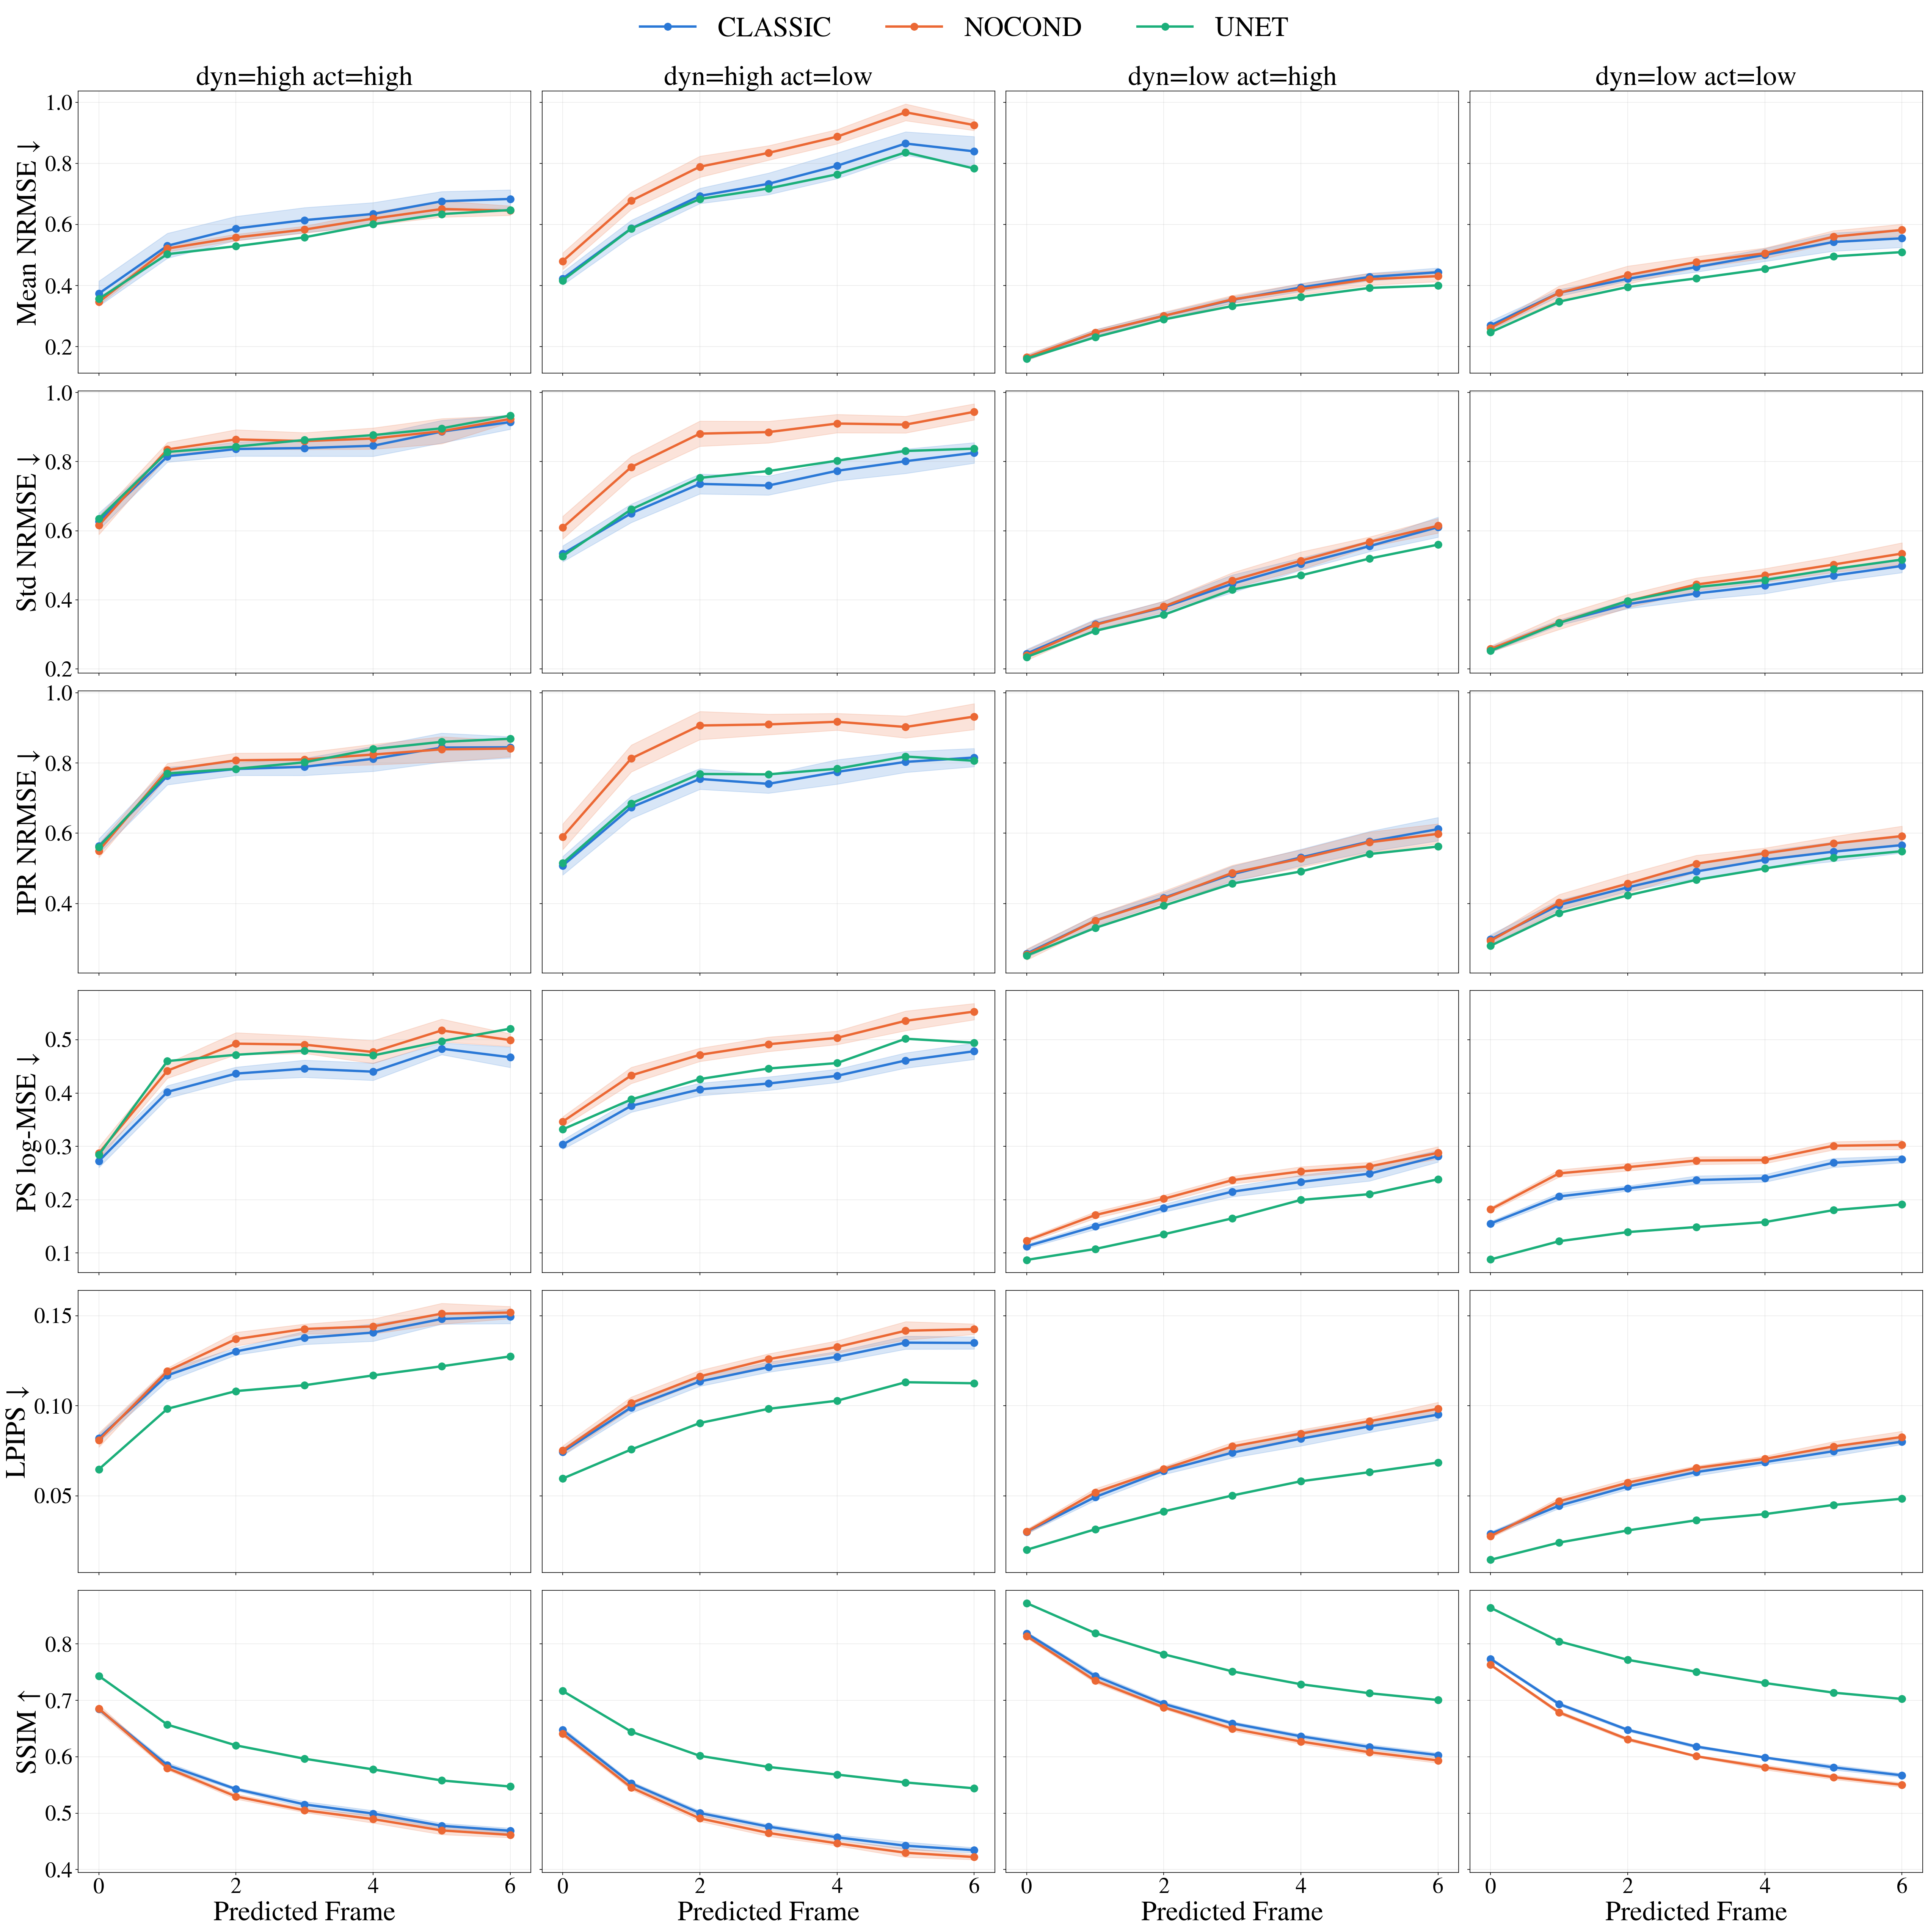

In [9]:
# =============================================================================
# Curve di degrado per frame_idx: righe = NRMSE(mean/std/cpcp) + PS log-MSE/LPIPS/SSIM, colonne = combo
# error bar (banda +-1 std tra i sample) per CLASSIC/NOCOND dove disponibile
# font grandi -- pensata per essere rimpicciolita in una colonna di paper
# =============================================================================
DEGRADATION_ROWS = [
    ('Mean NRMSE \u2193',  nrmse_by_frame_full, 'nrmse_mean_mean', 'nrmse_mean_std'),
    ('Std NRMSE \u2193',   nrmse_by_frame_full, 'nrmse_std_mean', 'nrmse_std_std'),
    ('IPR NRMSE \u2193',   nrmse_by_frame_full, 'nrmse_cpcp_mean', 'nrmse_cpcp_std'),
    ('PS log-MSE \u2193',  bar_by_frame_full,   'ps_log_mse_mean', 'ps_log_mse_std'),
    ('LPIPS \u2193',       bar_by_frame_full,   'lpips_mean', 'lpips_std'),
    ('SSIM \u2191',        bar_by_frame_full,   'ssim_mean', 'ssim_std'),
]

fig, axes = plt.subplots(len(DEGRADATION_ROWS), len(DYN_ACT),
                          figsize=(8.5 * len(DYN_ACT), 5.5 * len(DEGRADATION_ROWS)), sharex=True, sharey='row', dpi=300)

for col, (dyn, act) in enumerate(DYN_ACT):
    for row, (row_label, df, mean_col, std_col) in enumerate(DEGRADATION_ROWS):
        ax = axes[row, col]
        d_combo = df[(df['dyn'] == dyn) & (df['act'] == act)]
        for model_name in MODEL_ORDER:
            sub = d_combo[d_combo['model'] == model_name].sort_values('frame_idx')
            if sub.empty:
                continue
            ls = '--' if model_name == 'PERSISTENCE' else '-'
            ax.plot(sub['frame_idx'], sub[mean_col], color=MODEL_COLORS[model_name],
                    lw=3.0, ls=ls, marker='o', markersize=9, label=model_name)
            if model_name in ('CLASSIC', 'NOCOND') and std_col in sub.columns:
                mu, sig = sub[mean_col].values, sub[std_col].values
                lower = mu - sig if mean_col.startswith('nrmse_') is False else np.maximum(mu - sig, 0.0)
                ax.fill_between(sub['frame_idx'], lower, mu + sig,
                                 color=MODEL_COLORS[model_name], alpha=0.18)
        ax.grid(alpha=0.25)
        ax.tick_params(axis='both', labelsize=28)
        if row == 0:
            ax.set_title(f'dyn={dyn} act={act}', fontsize=35)
        if col == 0:
            ax.set_ylabel(row_label, fontsize=35)

for ax in axes[-1]:
    ax.set_xlabel('Predicted Frame', fontsize=35)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.035),
           ncol=len(MODEL_ORDER), fontsize=35, frameon=False)
#fig.suptitle('Degradation Along the Predicted Sequence', fontsize=42, y=1.07)
plt.tight_layout()

# figura per il paper (Test 1, Section 6.1) -- salvata anche qui, non solo in /tmp
PAPER_FIGURES_DIR = '/users/framunno/projects/paper_writing/SuperDARN_deep_Learning_Francesco/figures'
os.makedirs(PAPER_FIGURES_DIR, exist_ok=True)
fig.savefig(os.path.join(PAPER_FIGURES_DIR, 'singlepass_degradation_by_frame.png'),
            bbox_inches='tight', dpi=300)

show(fig, 'singlepass_degradation_by_frame.png')

## GIF / MP4 di una sequenza (opzionale)

Anima una singola sequenza singlepass (i 7 frame predetti) confrontando GT / CLASSIC / NOCOND / UNET in
vista polare. Le mappe sono gia' in coordinate cartesiane (`--cartesian-transform` in fase di generazione),
quindi niente conversione lat/lon come nel notebook 2015 — `pred`/`target` sono gia' direttamente
confrontabili pixel-per-pixel.

seq 0: 2020-03-23 02:22:00+00:00 -> 2020-03-23 02:34:00+00:00


/tmp/ipykernel_148783/2458157740.py:80: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im = ax.pcolormesh(theta_grid, r_grid, to_polar(frame), shading='auto', cmap='coolwarm', vmin=-VMAX, vmax=VMAX)


GIF saved: /tmp/singlepass_high_high_seq0.gif


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=2, resizing from (1781, 681) to (1782, 682) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x2f7f2dc0] Stream #0: not enough frames to estimate rate; consider increasing probesize


MP4 saved: /tmp/singlepass_high_high_seq0.mp4


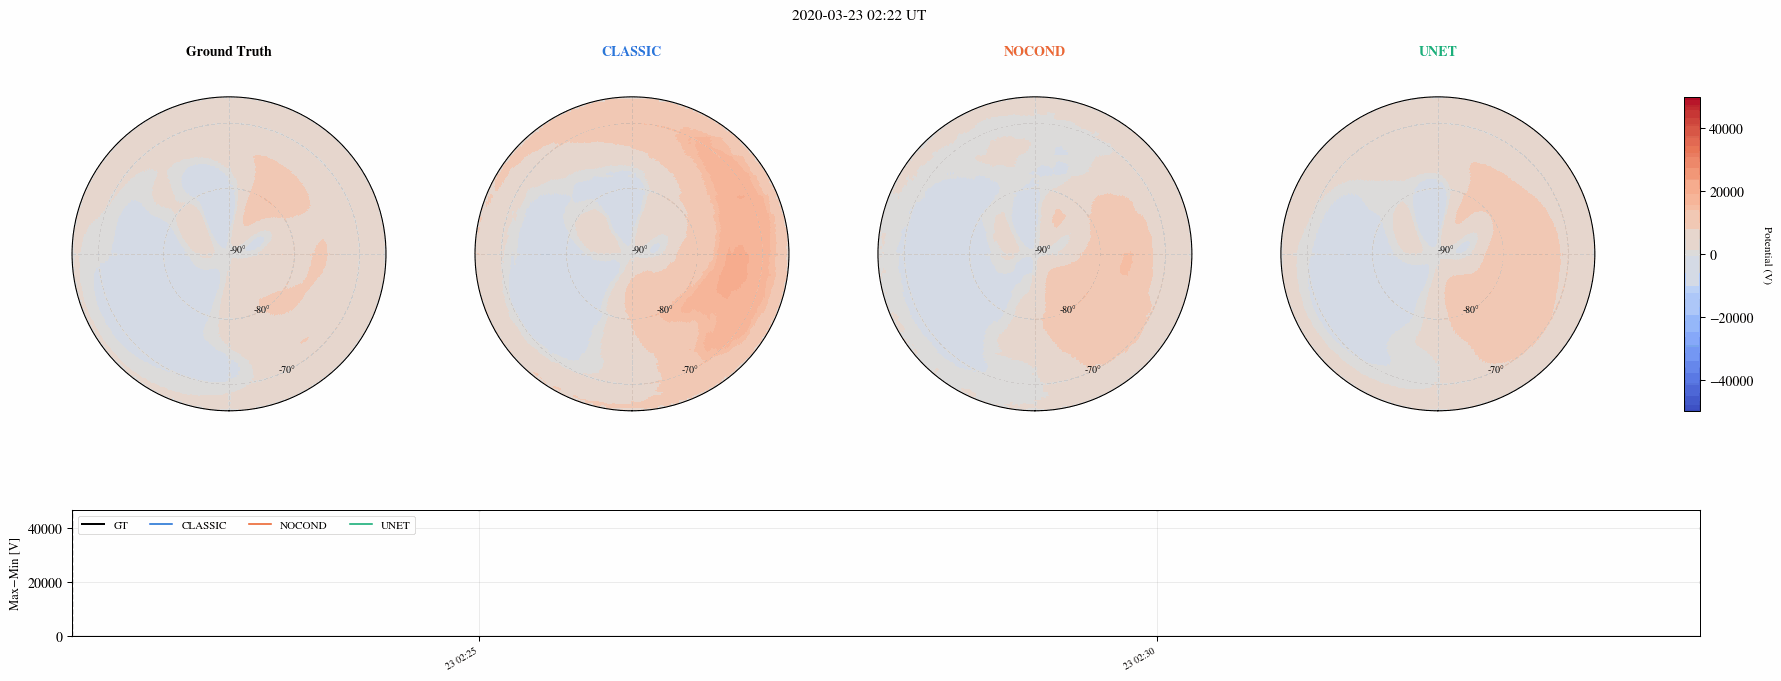

In [12]:
# =============================================================================
# CONFIG -- modifica qui quale sequenza animare
# =============================================================================
PLOT_DYN     = 'high'
PLOT_ACT     = 'high'
SEQ_IDX      = 0        # indice della sequenza (0..346 per acthigh, 0..652 per actlow)
SAMPLE_IDX   = 0        # quale sample diffusion mostrare (CLASSIC/NOCOND ne hanno 10)
FPS          = 3
VMAX         = 50000    # V, scala colore
SAVE_GIF     = True
SAVE_MP4     = True
GIF_PATH     = f'/tmp/singlepass_{PLOT_DYN}_{PLOT_ACT}_seq{SEQ_IDX}.gif'
MP4_PATH     = f'/tmp/singlepass_{PLOT_DYN}_{PLOT_ACT}_seq{SEQ_IDX}.mp4'

import io, json
from scipy.ndimage import map_coordinates
from matplotlib.gridspec import GridSpec
import imageio

def _load(model_name):
    d = MODEL_DIRS[model_name].format(dyn=PLOT_DYN, act=PLOT_ACT)
    pred_path = os.path.join(d, 'generated_imgs', f'pred_{SEQ_IDX}.npy')
    if not os.path.exists(pred_path):
        print(f'[{model_name}] mancante, salto')
        return None
    return np.load(pred_path).astype(np.float32)   # (n_samples, T, H, W), normalizzato

gt_dir = MODEL_DIRS['CLASSIC'].format(dyn=PLOT_DYN, act=PLOT_ACT) + '/ground_truth'
meta_path = MODEL_DIRS['CLASSIC'].format(dyn=PLOT_DYN, act=PLOT_ACT) + f'/metadata/meta_{SEQ_IDX}.json'
target = np.load(os.path.join(gt_dir, f'target_{SEQ_IDX}.npy')).astype(np.float32) * NORM_SCALE   # (T, H, W), volt
meta = json.load(open(meta_path))
pred_start = (pd.Timestamp(meta['start_time']).tz_localize('UTC')
              + pd.Timedelta(minutes=COND_FRAMES * FRAME_DT))
times = [pred_start + pd.Timedelta(minutes=FRAME_DT * i) for i in range(target.shape[0])]
print(f'seq {SEQ_IDX}: {times[0]} -> {times[-1]}')

PANELS_RAW = [('Ground Truth', 'black', None)]
for model_name, color in [('CLASSIC', MODEL_COLORS['CLASSIC']), ('NOCOND', MODEL_COLORS['NOCOND']), ('UNET', MODEL_COLORS['UNET'])]:
    arr = _load(model_name)
    if arr is not None:
        PANELS_RAW.append((model_name, color, arr))
n_p = len(PANELS_RAW)
T = target.shape[0]

gt_range_ts = (target.max(axis=(-2, -1)) - target.min(axis=(-2, -1)))
model_range_ts = {}
for lbl, col, arr in PANELS_RAW[1:]:
    s = SAMPLE_IDX if arr.shape[0] > 1 else 0
    model_range_ts[lbl] = (arr[s].max(axis=(-2, -1)) - arr[s].min(axis=(-2, -1))) * NORM_SCALE
ts_ymax = max(gt_range_ts.max(), *(v.max() for v in model_range_ts.values())) * 1.05

# --- griglia polare ---
H_IMG, max_r = 128, 24
r_i, th_i = np.linspace(0, max_r, 200), np.linspace(0, 2 * np.pi, 360)
r_grid, theta_grid = np.meshgrid(r_i, th_i)
polar_x, polar_y = r_grid * np.cos(theta_grid), r_grid * np.sin(theta_grid)
col_coords = (polar_x + max_r) / (2 * max_r) * (H_IMG - 1)
row_coords = (polar_y + max_r) / (2 * max_r) * (H_IMG - 1)

def to_polar(frame2d):
    return map_coordinates(frame2d, [row_coords, col_coords], order=1, mode='constant', cval=0)

frames_gif = []
for fi in range(T):
    t = times[fi]
    fig = plt.figure(figsize=(5 * n_p + 1, 7))
    gs = GridSpec(2, n_p + 1, width_ratios=[1] * n_p + [0.05], height_ratios=[3, 1.2],
                  hspace=0.45, wspace=0.35, figure=fig)
    ax_polars = [fig.add_subplot(gs[0, i], polar=True) for i in range(n_p)]
    ax_cbar = fig.add_subplot(gs[0, n_p])
    ax_ts = fig.add_subplot(gs[1, :])

    im_last = None
    for ax, (lbl, col, arr) in zip(ax_polars, PANELS_RAW):
        if arr is None:
            frame = target[fi]
        else:
            s = SAMPLE_IDX if arr.shape[0] > 1 else 0
            frame = np.clip(arr[s, fi] * NORM_SCALE, -3 * VMAX, 3 * VMAX)
        im = ax.pcolormesh(theta_grid, r_grid, to_polar(frame), shading='auto', cmap='coolwarm', vmin=-VMAX, vmax=VMAX)
        ax.set_theta_zero_location('S')
        ax.set_theta_direction(1)
        ax.set_title(lbl, fontsize=10, fontweight='bold', color=col, pad=30)
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.set_yticks([0, 10, 20])
        ax.set_yticklabels(['-90\u00b0', '-80\u00b0', '-70\u00b0'], fontsize=7)
        ax.set_xticks(np.radians([0, 90, 180, 270]))
        ax.set_xticklabels(['', '', '', ''])
        im_last = im

    plt.colorbar(im_last, cax=ax_cbar).set_label('Potential (V)', fontsize=8, rotation=270, labelpad=13)

    ax_ts.plot(times[:fi + 1], gt_range_ts[:fi + 1], color='black', lw=1.4, label='GT')
    for lbl, col, arr in PANELS_RAW[1:]:
        ax_ts.plot(times[:fi + 1], model_range_ts[lbl][:fi + 1], color=col, lw=1.2, label=lbl)
    ax_ts.axvline(t, color='gray', lw=1, ls='--', alpha=0.7)
    ax_ts.set_xlim(times[0], times[-1])
    ax_ts.set_ylim(0, ts_ymax)
    ax_ts.set_ylabel('Max\u2212Min [V]', fontsize=9)
    ax_ts.legend(fontsize=8, loc='upper left', ncol=n_p)
    ax_ts.grid(alpha=0.25)
    plt.setp(ax_ts.get_xticklabels(), rotation=30, ha='right', fontsize=7)

    fig.suptitle(t.strftime('%Y-%m-%d %H:%M UT'), fontsize=11, y=1.005)

    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    frames_gif.append(imageio.v2.imread(buf))

if SAVE_GIF:
    imageio.mimsave(GIF_PATH, frames_gif, fps=FPS, loop=0)
    print(f'GIF saved: {GIF_PATH}')
if SAVE_MP4:
    with imageio.get_writer(MP4_PATH, fps=FPS, codec='libx264', quality=8, macro_block_size=2) as writer:
        for frame in frames_gif:
            writer.append_data(frame)
    print(f'MP4 saved: {MP4_PATH}')

Image(GIF_PATH) if SAVE_GIF else None

## Valore predetto (non l'errore) di mean/std/IPR lungo la sequenza

Le curve sopra mostrano l'*errore* (NRMSE). Qui invece il *valore vero e proprio* predetto da ciascun
modello (+ GT di riferimento nero, + persistenza), per capire ad es. se un modello sovra/sottostima
sistematicamente l'IPR, non solo di quanto sbaglia. Uso `metrics_per_frame_v3.csv` (i valori grezzi,
gia' salvati da `compute_metrics_v3.py`) -- media sui sequenze per ogni sample, poi mean+-std sui sample
(stessa aggregazione in due passaggi usata ovunque nel notebook).

In [10]:
# =============================================================================
# Carica i CSV per-frame grezzi (cpcp_pred/gt, mean_pred/gt, std_pred/gt) per le 4 combo
# =============================================================================
def load_per_frame_csv():
    dfs = []
    for dyn, act in DYN_ACT:
        path = f'{METRICS_BASE}/metrics_v3_singlepass_dyn{dyn}_act{act}/metrics_per_frame_v3.csv'
        d = pd.read_csv(path)
        d['model'] = d['model'].str.upper()
        d['dyn'] = dyn
        d['act'] = act
        d['combo'] = f'{dyn}/{act}'
        dfs.append(d)
    return pd.concat(dfs, ignore_index=True)

raw_df = load_per_frame_csv()
print(raw_df.shape)
raw_df.head()

(332220, 16)


,model,seq_idx,frame_idx,sample_idx,mean_pred,std_pred,cpcp_pred,mean_gt,std_gt,cpcp_gt,ps_log_mse,lpips,ssim,dyn,act,combo
0,CLASSIC,0,0,0,5251.285645,6956.708496,11199.609375,1701.55127,3365.254639,3429.589844,1.315355,0.269302,0.368186,high,high,high/high
1,CLASSIC,0,0,1,3300.739990,3956.092529,5698.597656,1701.55127,3365.254639,3429.589844,0.420961,0.064411,0.607765,high,high,high/high
2,CLASSIC,0,0,2,3058.972412,6213.693359,7677.589844,1701.55127,3365.254639,3429.589844,0.770689,0.164614,0.515181,high,high,high/high
3,CLASSIC,0,0,3,5635.153320,6033.877930,9587.763672,1701.55127,3365.254639,3429.589844,0.984160,0.221212,0.421624,high,high,high/high
4,CLASSIC,0,0,4,3480.227539,7533.604492,9810.197266,1701.55127,3365.254639,3429.589844,0.944242,0.206155,0.367864,high,high,high/high


In [11]:
# =============================================================================
# Griglia: righe = mean/std/cpcp(IPR), colonne = combo -- valore predetto vs GT vs persistenza
# =============================================================================
RAW_STATS = ['mean', 'std', 'cpcp']
RAW_DISPLAY = {'mean': 'Mean', 'std': 'Standard Deviation', 'cpcp': 'Interquartile Potential Range'}

def raw_pred_curve(model_name, stat, combo):
    d = raw_df[(raw_df['model'] == model_name) & (raw_df['combo'] == combo)]
    per_sample = d.groupby(['frame_idx', 'sample_idx'])[f'{stat}_pred'].mean()   # media sulle sequenze
    mu  = per_sample.groupby('frame_idx').mean()
    sig = per_sample.groupby('frame_idx').std().fillna(0.0)                      # std tra i sample
    return mu, sig

def raw_gt_curve(stat, combo):
    # la GT e' identica tra i modelli per la stessa (seq, frame): la prendo da un solo modello/sample
    d = raw_df[(raw_df['model'] == 'CLASSIC') & (raw_df['sample_idx'] == 0) & (raw_df['combo'] == combo)]
    return d.groupby('frame_idx')[f'{stat}_gt'].mean()

def raw_persistence_curve(stat, combo):
    d = persistence_df[persistence_df['combo'] == combo]
    return d.groupby('frame_idx')[f'{stat}_pred'].mean()

fig, axes = plt.subplots(len(RAW_STATS), len(DYN_ACT),
                          figsize=(5.5 * len(DYN_ACT), 3.2 * len(RAW_STATS)), sharex=True, dpi=300)

for col, (dyn, act) in enumerate(DYN_ACT):
    combo = f'{dyn}/{act}'
    for row, stat in enumerate(RAW_STATS):
        ax = axes[row, col]

        gt = raw_gt_curve(stat, combo)
        ax.plot(gt.index, gt.values, color='black', lw=1.6, label='GT', zorder=5)

        for model_name in ['CLASSIC', 'NOCOND', 'UNET']:
            mu, sig = raw_pred_curve(model_name, stat, combo)
            ax.plot(mu.index, mu.values, color=MODEL_COLORS[model_name], lw=1.3, label=model_name)
            if model_name != 'UNET':
                ax.fill_between(mu.index, mu.values - sig.values, mu.values + sig.values,
                                 color=MODEL_COLORS[model_name], alpha=0.18)

        pers = raw_persistence_curve(stat, combo)
        ax.plot(pers.index, pers.values, color=MODEL_COLORS['PERSISTENCE'], lw=1.3, ls='--', label='PERSISTENCE')

        ax.grid(alpha=0.25)
        if row == 0:
            ax.set_title(f'dyn={dyn} act={act}', fontsize=16)
        if col == 0:
            ax.set_ylabel(RAW_DISPLAY.get(stat, stat), fontsize=13)

for ax in axes[-1]:
    ax.set_xlabel('frame_idx', fontsize=13)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05),
           ncol=5, fontsize=14, frameon=False)
fig.suptitle('Valore predetto vs GT lungo la sequenza', fontsize=22, y=1.13)
plt.tight_layout()
show(fig, 'singlepass_raw_value_by_frame.png')

KeyError: 'combo'

## Trova la sequenza piu' estrema in una combo (utile per scegliere `SEQ_IDX` nella GIF)

Due criteri diversi: **intensita' massima** (IPR/cpcp piu' alta raggiunta nella finestra predetta) vs
**dinamismo** (quanto si sposta il potenziale medio durante i 14 minuti) -- non sono sempre la stessa
sequenza.

In [12]:
# =============================================================================
# Sequenze piu' estreme in una combo (usa metrics_per_frame_v3.csv, gia' caricato come raw_df se
# hai girato la sezione "valore predetto" sopra; altrimenti lo ricarico qui per la sola combo scelta)
# =============================================================================
FIND_DYN, FIND_ACT = 'high', 'high'

d = f'{METRICS_BASE}/metrics_v3_singlepass_dyn{FIND_DYN}_act{FIND_ACT}'
gt_only = pd.read_csv(f'{d}/metrics_per_frame_v3.csv')
gt_only = gt_only[(gt_only['model'].str.upper() == 'CLASSIC') & (gt_only['sample_idx'] == 0)]

per_seq = gt_only.groupby('seq_idx').agg(
    max_cpcp_gt=('cpcp_gt', 'max'),
    range_mean_gt=('mean_gt', lambda x: x.max() - x.min()),
)

print(f'=== dyn={FIND_DYN} act={FIND_ACT}: top 5 per intensita\' massima (IPR) ===')
print(per_seq.sort_values('max_cpcp_gt', ascending=False).head(5))
print(f'\n=== dyn={FIND_DYN} act={FIND_ACT}: top 5 per dinamismo (escursione mean) ===')
print(per_seq.sort_values('range_mean_gt', ascending=False).head(5))

=== dyn=high act=high: top 5 per intensita' massima (IPR) ===
          max_cpcp_gt  range_mean_gt
seq_idx                             
43       51316.566406   17670.593750
321      48417.886719   18851.749023
308      48121.207031    9811.648438
322      47210.312500   13409.941406
428      45353.546875   15967.236328

=== dyn=high act=high: top 5 per dinamismo (escursione mean) ===
          max_cpcp_gt  range_mean_gt
seq_idx                             
235      35025.218750   30861.920898
38       30348.070312   25317.517578
166      31500.484375   25170.451660
451      25655.175781   20724.065430
347      25442.832031   20598.192383


## Curva di degrado del caso piu' estremo (non media su tutte le sequenze)

Solo per una `seq_idx` specifica dentro `dynhigh/acthigh` -- niente NRMSE con normalizzazione sulla
popolazione (con 1 sola sequenza non avrebbe senso), mostro direttamente valore predetto vs GT (con
banda +-1 std tra i 10 sample) per mean/std/IPR, e PS log-MSE/LPIPS/SSIM (idem). Richiede `raw_df`
gia' caricato nella sezione "valore predetto" sopra.

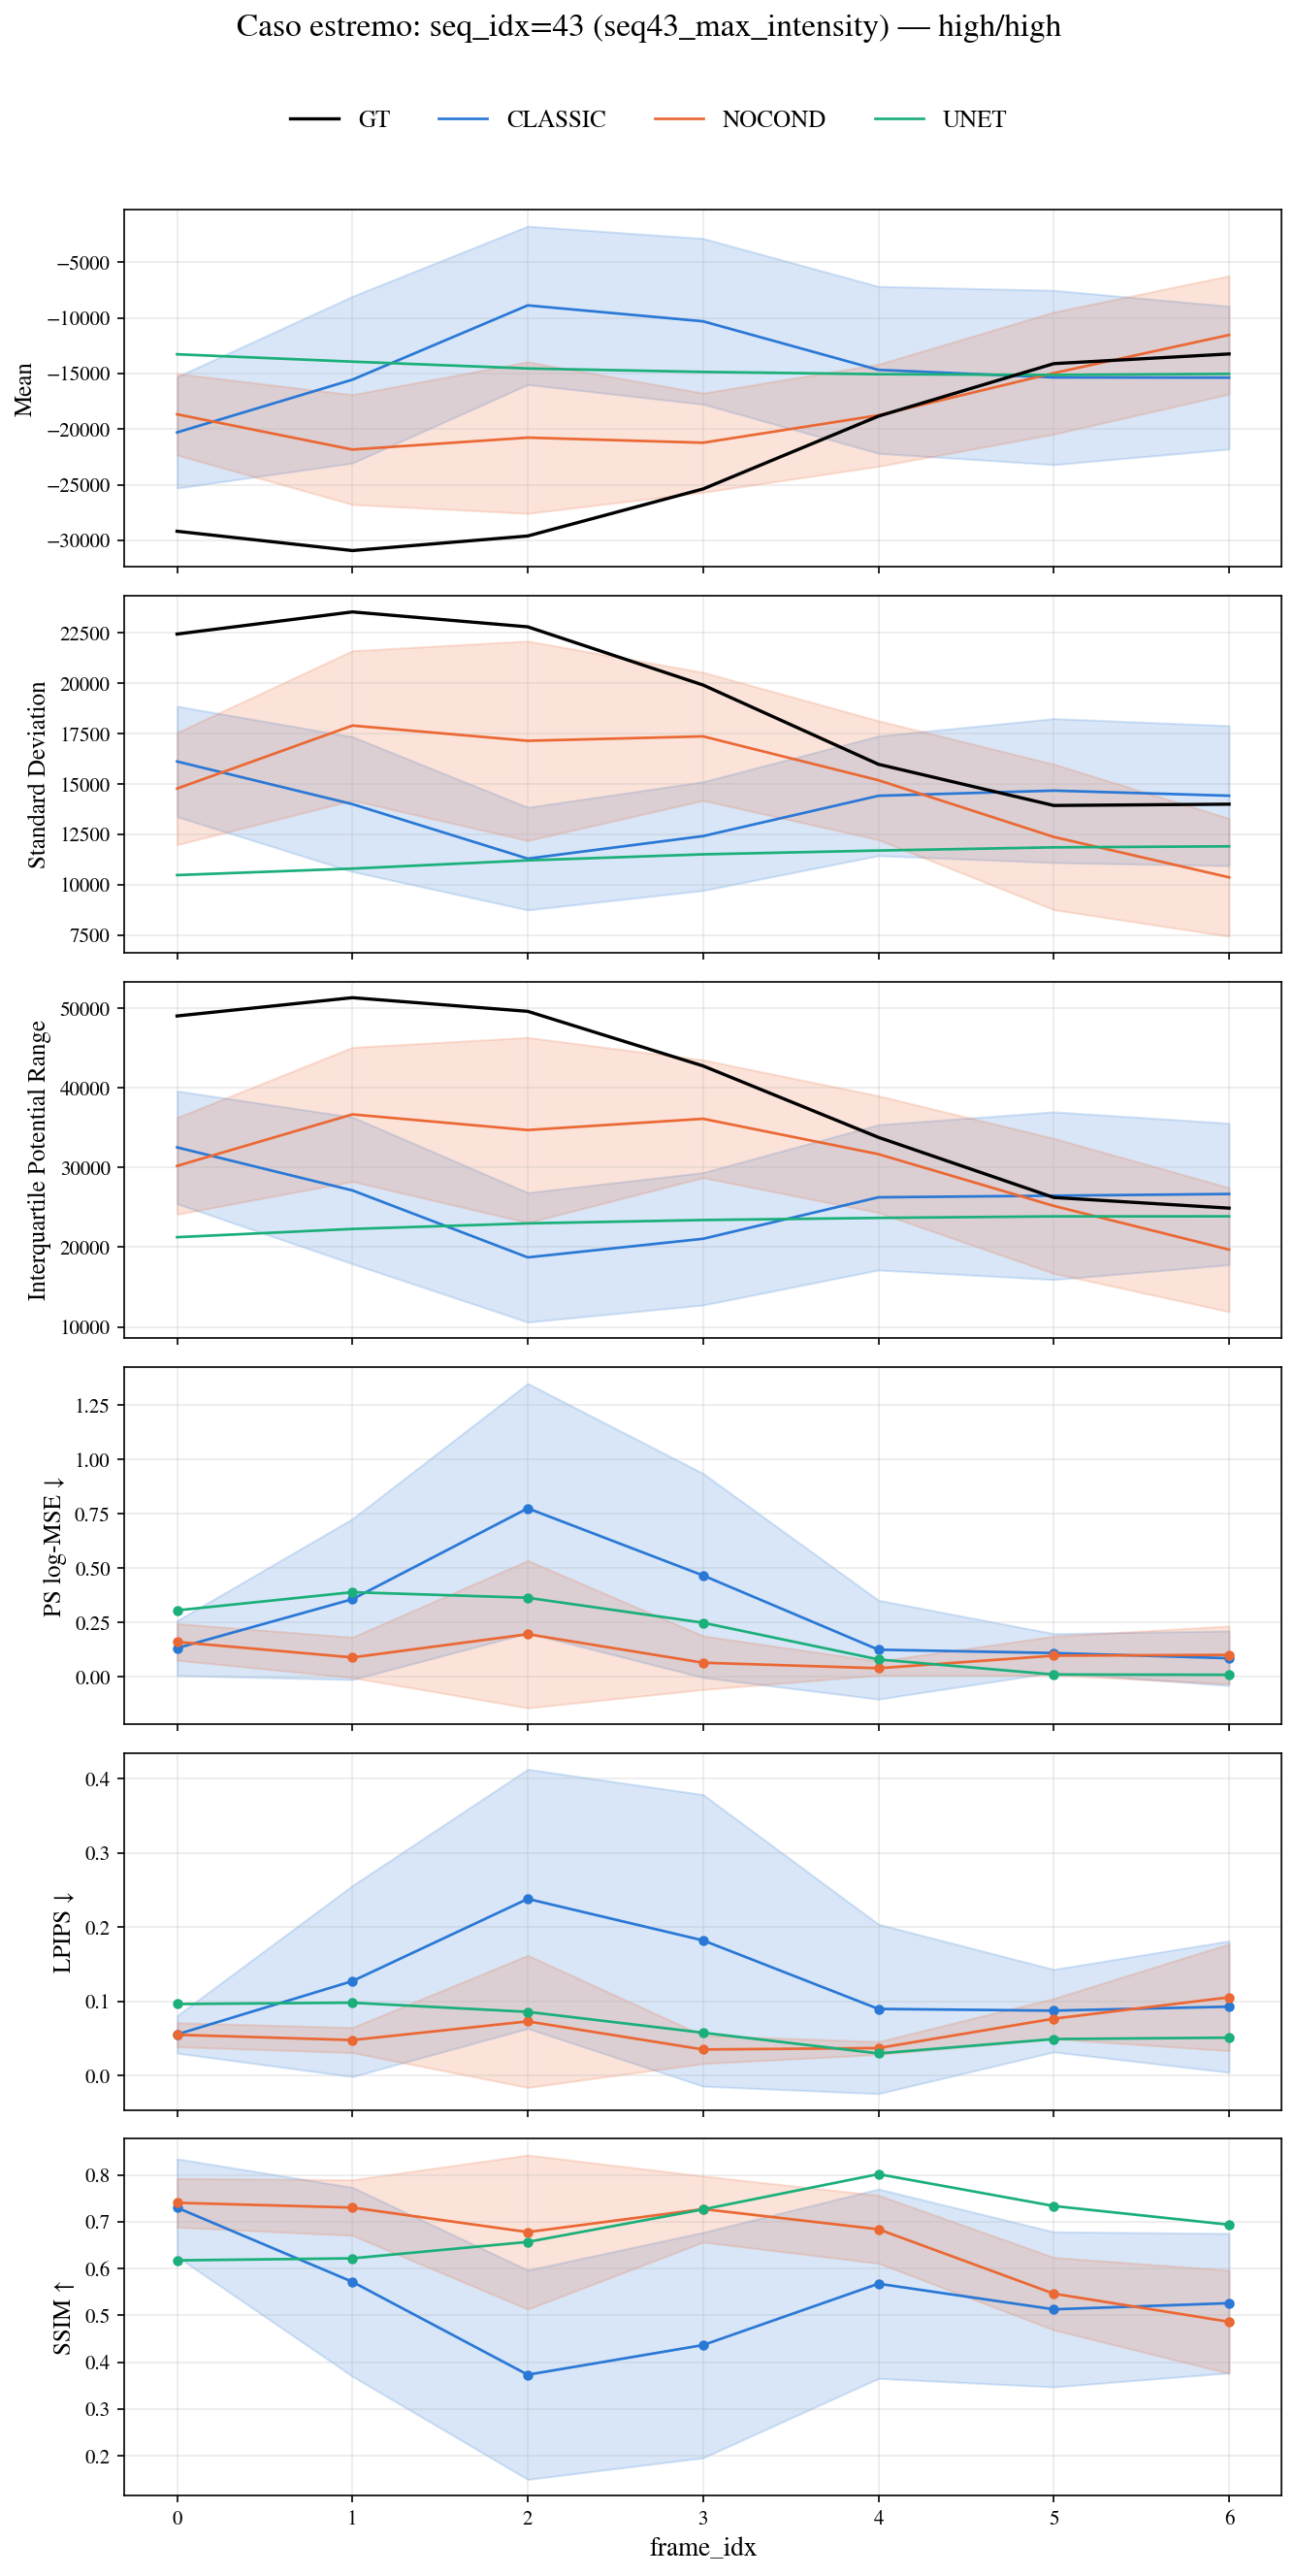

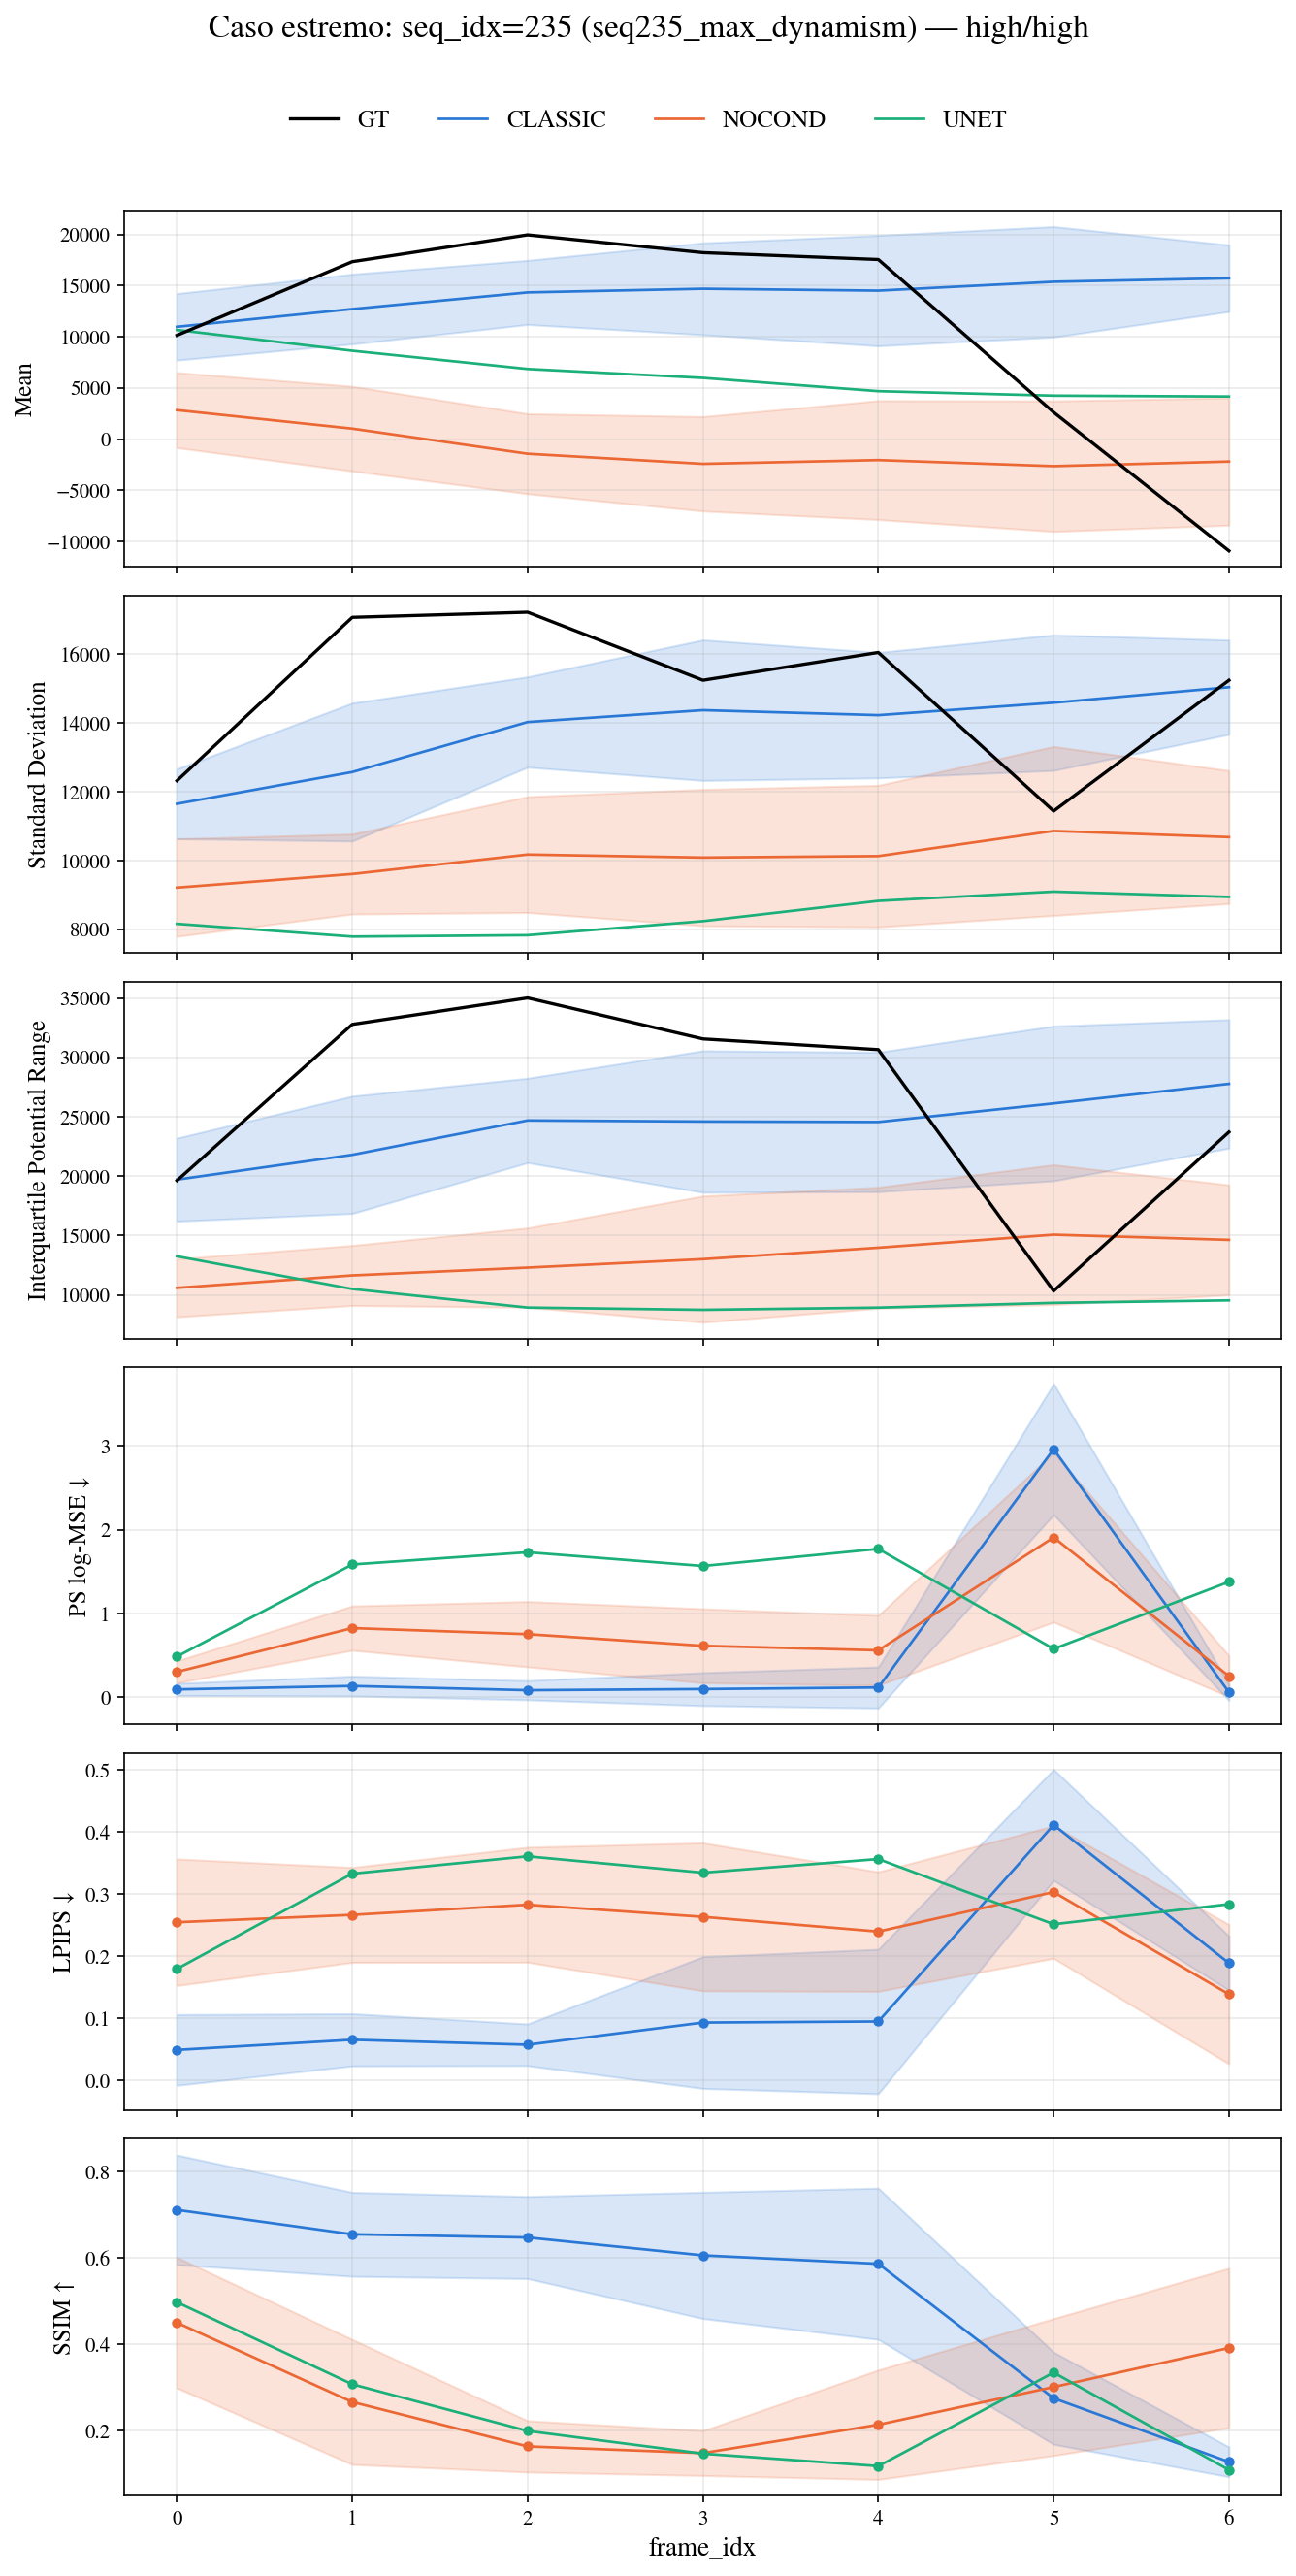

In [13]:
# =============================================================================
# Griglia verticale per UNA sequenza specifica: mean/std/IPR + PS log-MSE/LPIPS/SSIM vs frame_idx
# =============================================================================
EXTREME_COMBO = 'high/high'
EXTREME_CASES = {'seq43_max_intensity': 43, 'seq235_max_dynamism': 235}   # dalla cella "trova la sequenza piu' estrema"

SCALAR_ROWS = [('Mean', 'mean'), ('Standard Deviation', 'std'), ('Interquartile Potential Range', 'cpcp')]
PIXEL_ROWS  = [('PS log-MSE \u2193', 'ps_log_mse'), ('LPIPS \u2193', 'lpips'), ('SSIM \u2191', 'ssim')]
CASE_MODELS = ['CLASSIC', 'NOCOND', 'UNET']

for case_name, seq_idx in EXTREME_CASES.items():
    d_seq = raw_df[(raw_df['combo'] == EXTREME_COMBO) & (raw_df['seq_idx'] == seq_idx)]

    n_rows = len(SCALAR_ROWS) + len(PIXEL_ROWS)
    fig, axes = plt.subplots(n_rows, 1, figsize=(9, 2.8 * n_rows), sharex=True, dpi=300)

    for i, (label, stat) in enumerate(SCALAR_ROWS):
        ax = axes[i]
        gt = (d_seq[(d_seq['model'] == 'CLASSIC') & (d_seq['sample_idx'] == 0)]
              .sort_values('frame_idx'))
        ax.plot(gt['frame_idx'], gt[f'{stat}_gt'], color='black', lw=1.6, label='GT', zorder=5)
        for model_name in CASE_MODELS:
            g = d_seq[d_seq['model'] == model_name].groupby('frame_idx')[f'{stat}_pred']
            mu, sig = g.mean(), g.std().fillna(0.0)
            ax.plot(mu.index, mu.values, color=MODEL_COLORS[model_name], lw=1.3, label=model_name)
            if model_name != 'UNET':
                ax.fill_between(mu.index, mu.values - sig.values, mu.values + sig.values,
                                 color=MODEL_COLORS[model_name], alpha=0.18)
        ax.set_ylabel(label, fontsize=12)
        ax.grid(alpha=0.25)

    for j, (label, col) in enumerate(PIXEL_ROWS):
        ax = axes[len(SCALAR_ROWS) + j]
        for model_name in CASE_MODELS:
            g = d_seq[d_seq['model'] == model_name].groupby('frame_idx')[col]
            mu, sig = g.mean(), g.std().fillna(0.0)
            ax.plot(mu.index, mu.values, color=MODEL_COLORS[model_name], lw=1.3,
                    marker='o', markersize=4, label=model_name)
            if model_name != 'UNET':
                ax.fill_between(mu.index, mu.values - sig.values, mu.values + sig.values,
                                 color=MODEL_COLORS[model_name], alpha=0.18)
        ax.set_ylabel(label, fontsize=12)
        ax.grid(alpha=0.25)

    axes[-1].set_xlabel('frame_idx', fontsize=13)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=4, fontsize=12, frameon=False)
    fig.suptitle(f'Caso estremo: seq_idx={seq_idx} ({case_name}) \u2014 {EXTREME_COMBO}', fontsize=16, y=1.05)
    plt.tight_layout()
    show(fig, f'singlepass_extreme_{case_name}.png')

## L'inerzia ionosferica su 14 minuti maschera il vantaggio di CLASSIC nell'aggregato

Ipotesi: anche dentro `dynhigh/acthigh` (gia' il 25% piu' dinamico/attivo), la maggior parte delle
477 sequenze non cambia abbastanza in 14 minuti perche' il vantaggio di CLASSIC emerga -- solo le poche
sequenze *davvero* dinamiche lo mostrano (es. seq_idx=235). L'aggregato per strato media tutto insieme
e lo nasconde.

**Verifica**: uno scatter per-sequenza, non un altro bar chart aggregato -- x = quanto e' *davvero*
cambiato il campo in quella specifica finestra (dinamismo reale della sequenza), y = quanto CLASSIC
batte UNET su quella sequenza (IPR e PS log-MSE, le due metriche piu' legate all'ampiezza/dinamismo
e all'unica dove CLASSIC vince gia' in aggregato). Se l'ipotesi e' giusta ci deve essere una
correlazione positiva chiara, anche se l'aggregato dice il contrario.

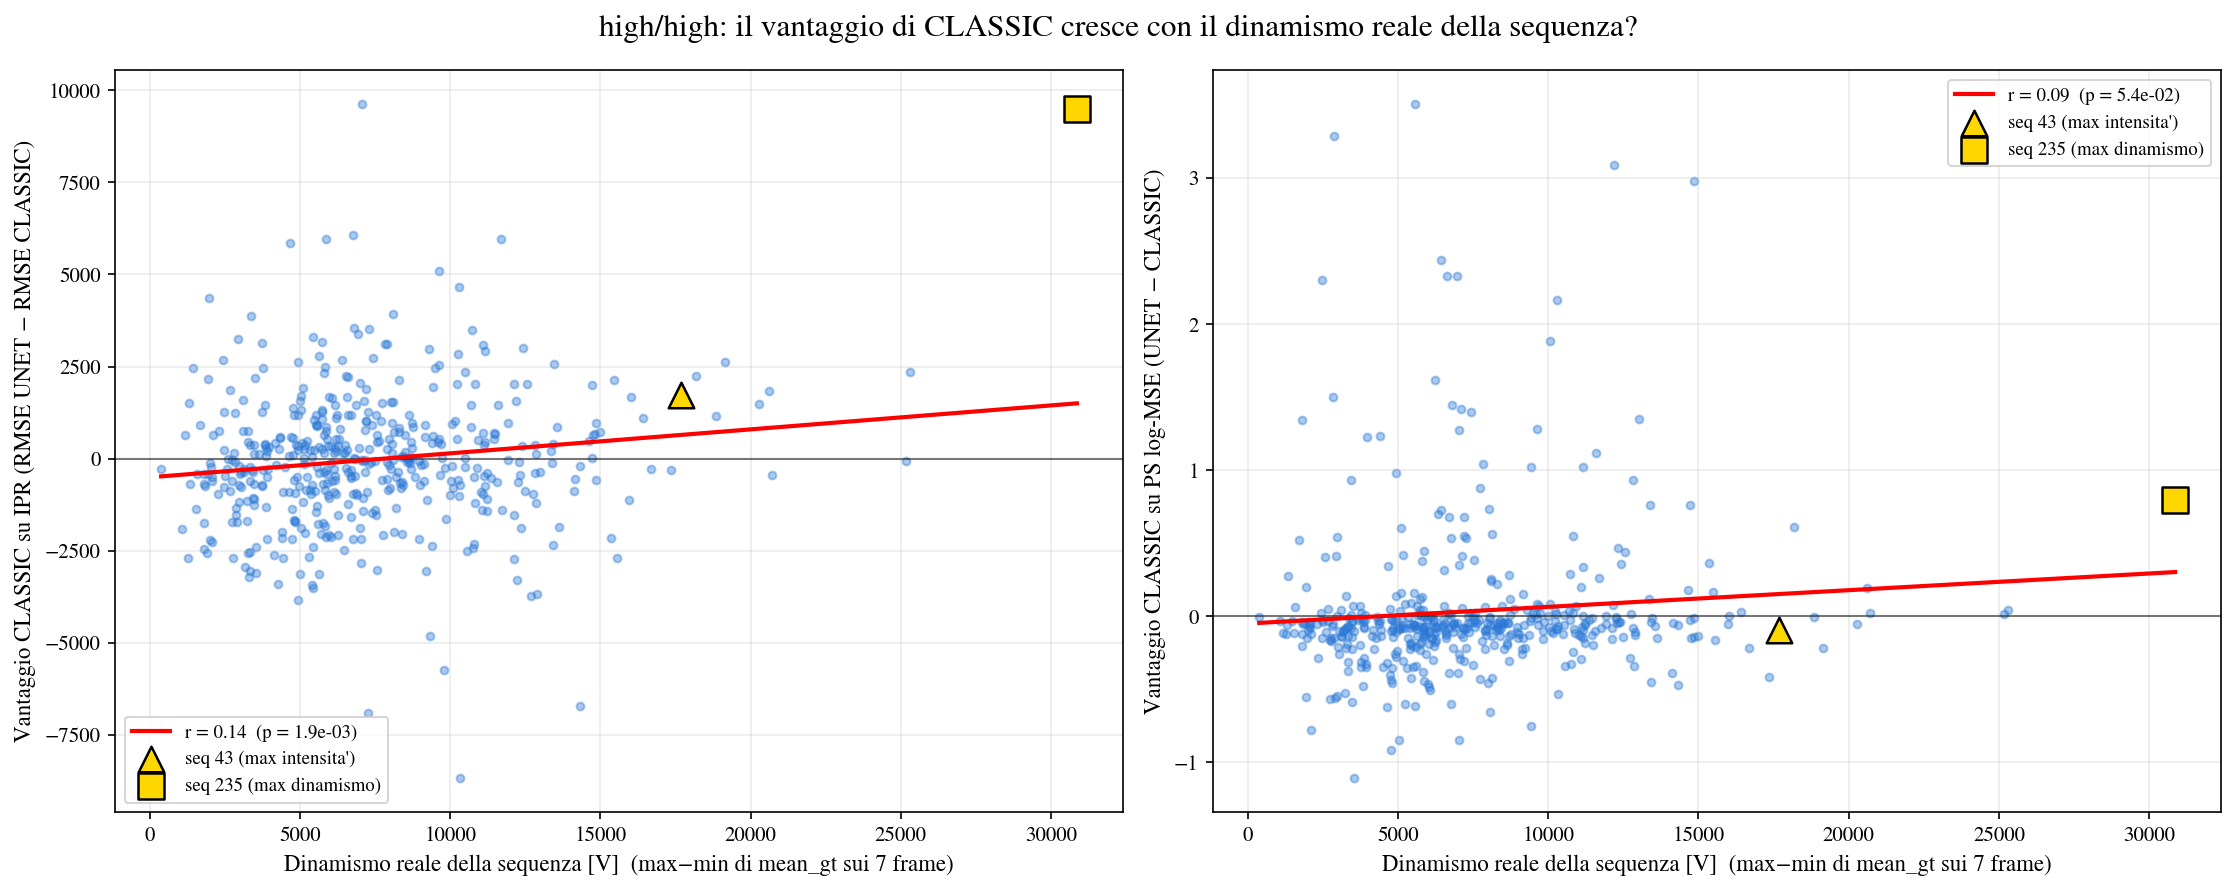

 seq_idx     dynamism  advantage_ipr  advantage_ps
     235 30861.920898    9479.501280      0.792209
      38 25317.517578    2341.915854      0.040613
     166 25170.451660     -73.973254      0.017651
     451 20724.065430    -451.241695      0.024183
     347 20598.192383    1834.235033      0.191284
     349 20269.907715    1490.646336     -0.050857
      67 19149.271973    2618.611350     -0.218361
     321 18851.749023    1147.855833     -0.008139
     390 18191.550293    2240.863098      0.611408
      43 17670.593750    1727.498345     -0.091854

Soglia top 10% dinamismo: 12397 V  (48 sequenze su 477)

=== IPR ===
  Spearman rho = 0.126  (p = 0.006)
  vantaggio medio CLASSIC -- top 10% dinamismo: 237.020   resto: -55.701
  % sequenze dove CLASSIC vince -- top 10%: 54%   resto: 46%

=== PS log-MSE ===
  Spearman rho = 0.145  (p = 0.001)
  vantaggio medio CLASSIC -- top 10% dinamismo: 0.118   resto: 0.024
  % sequenze dove CLASSIC vince -- top 10%: 42%   resto: 28%



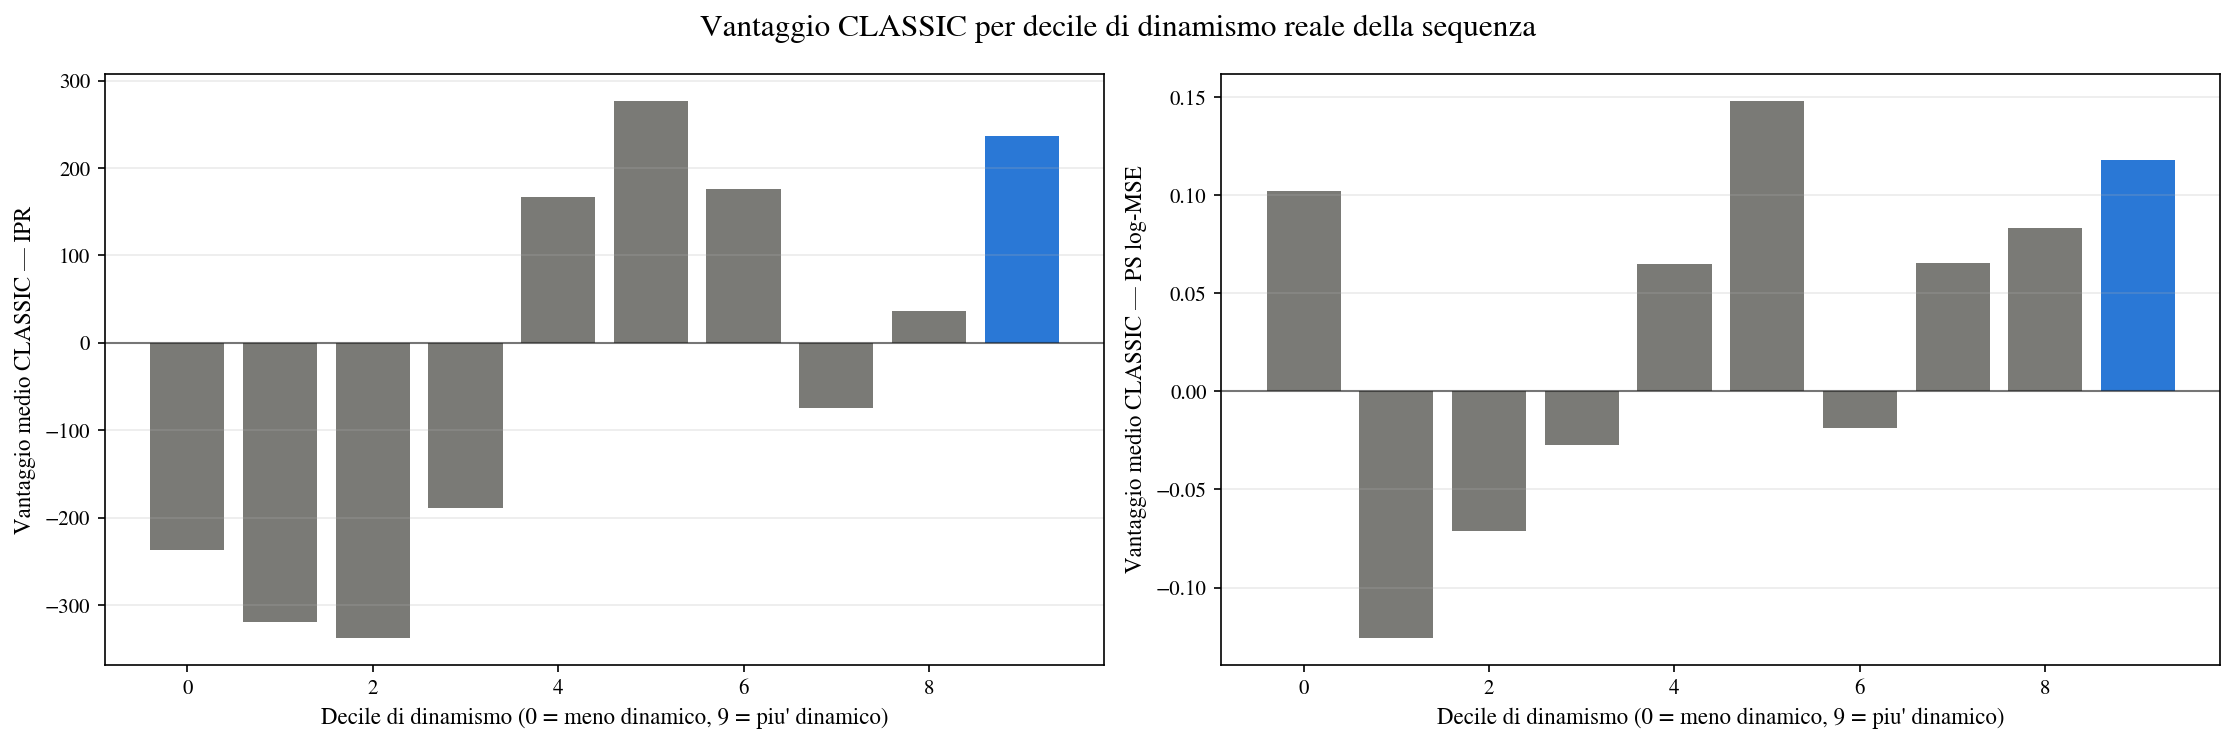

In [14]:
# =============================================================================
# Scatter per-sequenza: dinamismo reale vs vantaggio CLASSIC-su-UNET (dynhigh/acthigh)
# =============================================================================
from scipy.stats import pearsonr

SCATTER_COMBO = 'high/high'
d_combo = raw_df[raw_df['combo'] == SCATTER_COMBO]

records = []
for seq_idx, d_seq in d_combo.groupby('seq_idx'):
    gt = d_seq[(d_seq['model'] == 'CLASSIC') & (d_seq['sample_idx'] == 0)].sort_values('frame_idx')
    dynamism = gt['mean_gt'].max() - gt['mean_gt'].min()   # quanto si sposta davvero il potenziale medio

    # --- IPR: RMSE per-sequenza, CLASSIC sull'ensemble-mean dei 10 sample vs UNET (1 sample) ---
    classic_ipr_pred = (d_seq[d_seq['model'] == 'CLASSIC']
                         .groupby('frame_idx')['cpcp_pred'].mean())          # ensemble-mean per frame
    unet_ipr_pred = (d_seq[d_seq['model'] == 'UNET']
                      .groupby('frame_idx')['cpcp_pred'].mean())
    ipr_gt = gt.set_index('frame_idx')['cpcp_gt']

    rmse_classic_ipr = np.sqrt(np.mean((classic_ipr_pred - ipr_gt) ** 2))
    rmse_unet_ipr     = np.sqrt(np.mean((unet_ipr_pred - ipr_gt) ** 2))
    advantage_ipr = rmse_unet_ipr - rmse_classic_ipr   # positivo = CLASSIC vince su questa sequenza

    # --- PS log-MSE: media sui sample poi sui frame (per-sequenza) ---
    classic_ps = d_seq[d_seq['model'] == 'CLASSIC']['ps_log_mse'].mean()
    unet_ps    = d_seq[d_seq['model'] == 'UNET']['ps_log_mse'].mean()
    advantage_ps = unet_ps - classic_ps   # positivo = CLASSIC vince (piu' basso e' meglio)

    records.append({'seq_idx': seq_idx, 'dynamism': dynamism,
                     'advantage_ipr': advantage_ipr, 'advantage_ps': advantage_ps})

adv_df = pd.DataFrame(records)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), dpi=300)

for ax, col, title in [(axes[0], 'advantage_ipr', 'Vantaggio CLASSIC su IPR (RMSE UNET \u2212 RMSE CLASSIC)'),
                        (axes[1], 'advantage_ps',  'Vantaggio CLASSIC su PS log-MSE (UNET \u2212 CLASSIC)')]:
    ax.scatter(adv_df['dynamism'], adv_df[col], s=14, alpha=0.4, color=MODEL_COLORS['CLASSIC'])
    ax.axhline(0, color='black', lw=1, alpha=0.5)

    # retta di tendenza + correlazione
    r, p = pearsonr(adv_df['dynamism'], adv_df[col])
    z = np.polyfit(adv_df['dynamism'], adv_df[col], 1)
    xs = np.linspace(adv_df['dynamism'].min(), adv_df['dynamism'].max(), 50)
    ax.plot(xs, np.polyval(z, xs), color='red', lw=2, label=f'r = {r:.2f}  (p = {p:.1e})')

    # evidenzia le due sequenze estreme trovate prima
    for seq_idx, mk, lbl in [(43, '^', 'seq 43 (max intensita\')'), (235, 's', 'seq 235 (max dinamismo)')]:
        row = adv_df[adv_df['seq_idx'] == seq_idx]
        if len(row):
            ax.scatter(row['dynamism'], row[col], s=150, marker=mk, color='gold',
                       edgecolor='black', linewidth=1.2, zorder=5, label=lbl)

    ax.set_xlabel('Dinamismo reale della sequenza [V]  (max\u2212min di mean_gt sui 7 frame)', fontsize=11)
    ax.set_ylabel(title, fontsize=11)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=9)

fig.suptitle(f'{SCATTER_COMBO}: il vantaggio di CLASSIC cresce con il dinamismo reale della sequenza?', fontsize=15)
plt.tight_layout()
show(fig, 'singlepass_dynamism_vs_classic_advantage.png')

print(adv_df.sort_values('dynamism', ascending=False).head(10).to_string(index=False))

# =============================================================================
# Pearson e' sensibile agli outlier e assume una relazione lineare su tutto il range.
# L'ipotesi vera e' "a soglia": solo i casi DAVVERO estremi (coda della distribuzione) contano,
# non un trend graduale su tutte le sequenze -- quindi aggiungo due test piu' adatti:
#  1) Spearman (rango): robusto a outlier/non-linearita', dice solo se il trend e' monotono
#  2) top-decile (10% piu' dinamico) vs il resto: la domanda vera che stiamo facendo
# =============================================================================
from scipy.stats import spearmanr

threshold = adv_df['dynamism'].quantile(0.90)
top_decile = adv_df[adv_df['dynamism'] >= threshold]
rest       = adv_df[adv_df['dynamism'] <  threshold]

print(f"\nSoglia top 10% dinamismo: {threshold:.0f} V  ({len(top_decile)} sequenze su {len(adv_df)})\n")

for col, name in [('advantage_ipr', 'IPR'), ('advantage_ps', 'PS log-MSE')]:
    rho, p_rho = spearmanr(adv_df['dynamism'], adv_df[col])
    print(f"=== {name} ===")
    print(f"  Spearman rho = {rho:.3f}  (p = {p_rho:.3f})")
    print(f"  vantaggio medio CLASSIC -- top 10% dinamismo: {top_decile[col].mean():.3f}   "
          f"resto: {rest[col].mean():.3f}")
    print(f"  % sequenze dove CLASSIC vince -- top 10%: {(top_decile[col] > 0).mean()*100:.0f}%   "
          f"resto: {(rest[col] > 0).mean()*100:.0f}%\n")

# --- bar chart: vantaggio medio per decile di dinamismo (10 bin di uguale numerosita') ---
adv_df['dynamism_decile'] = pd.qcut(adv_df['dynamism'], 10, labels=False, duplicates='drop')

fig, axes = plt.subplots(1, 2, figsize=(15, 5), dpi=300)
for ax, col, name in [(axes[0], 'advantage_ipr', 'IPR'), (axes[1], 'advantage_ps', 'PS log-MSE')]:
    by_decile = adv_df.groupby('dynamism_decile')[col].mean()
    colors = ['#7a7a76'] * (len(by_decile) - 1) + [MODEL_COLORS['CLASSIC']]   # ultimo decile evidenziato
    ax.bar(by_decile.index, by_decile.values, color=colors)
    ax.axhline(0, color='black', lw=1, alpha=0.5)
    ax.set_xlabel('Decile di dinamismo (0 = meno dinamico, 9 = piu\' dinamico)', fontsize=11)
    ax.set_ylabel(f'Vantaggio medio CLASSIC \u2014 {name}', fontsize=11)
    ax.grid(alpha=0.25, axis='y')
fig.suptitle('Vantaggio CLASSIC per decile di dinamismo reale della sequenza', fontsize=15)
plt.tight_layout()
show(fig, 'singlepass_dynamism_decile_advantage.png')

## L'effetto speculare: UNET vince a bassa dinamicita', CLASSIC ad alta -- su tutto lo spettro

Lo scatter sopra guardava solo dentro `dynhigh/acthigh` (gia' la coda alta). Qui invece uso **tutte le
sequenze di tutte e 4 le combo** (~2260 sequenze), per vedere l'intero spettro di dinamismo reale, non solo
la sua coda -- l'ipotesi e' che il vantaggio di CLASSIC cresca monotonicamente con il dinamismo, passando da
negativo (UNET vince, la sua inerzia/smoothing e' un prior corretto quando il campo non cambia) a positivo
(CLASSIC vince, la sua diversita' stocastica paga quando il campo cambia davvero).

In [ ]:
# =============================================================================
# Scatter su TUTTE le sequenze (tutte e 4 le combo): dinamismo reale vs vantaggio CLASSIC-su-UNET
# =============================================================================
records_all = []
for combo in raw_df['combo'].unique():
    d_combo = raw_df[raw_df['combo'] == combo]
    for seq_idx, d_seq in d_combo.groupby('seq_idx'):
        gt = d_seq[(d_seq['model'] == 'CLASSIC') & (d_seq['sample_idx'] == 0)].sort_values('frame_idx')
        dynamism = gt['mean_gt'].max() - gt['mean_gt'].min()

        classic_ipr_pred = d_seq[d_seq['model'] == 'CLASSIC'].groupby('frame_idx')['cpcp_pred'].mean()
        unet_ipr_pred    = d_seq[d_seq['model'] == 'UNET'].groupby('frame_idx')['cpcp_pred'].mean()
        ipr_gt = gt.set_index('frame_idx')['cpcp_gt']

        rmse_classic_ipr = np.sqrt(np.mean((classic_ipr_pred - ipr_gt) ** 2))
        rmse_unet_ipr    = np.sqrt(np.mean((unet_ipr_pred - ipr_gt) ** 2))
        advantage_ipr = rmse_unet_ipr - rmse_classic_ipr

        classic_ps = d_seq[d_seq['model'] == 'CLASSIC']['ps_log_mse'].mean()
        unet_ps    = d_seq[d_seq['model'] == 'UNET']['ps_log_mse'].mean()
        advantage_ps = unet_ps - classic_ps

        records_all.append({'combo': combo, 'seq_idx': seq_idx, 'dynamism': dynamism,
                             'advantage_ipr': advantage_ipr, 'advantage_ps': advantage_ps})

adv_all_df = pd.DataFrame(records_all)
print(f'{len(adv_all_df)} sequenze totali (tutte le combo)')

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), dpi=300)

for ax, col, title in [(axes[0], 'advantage_ipr', 'CLASSIC advantage on IPR (UNET RMSE \u2212 CLASSIC RMSE)'),
                        (axes[1], 'advantage_ps',  'CLASSIC advantage on PS log-MSE (UNET \u2212 CLASSIC)')]:
    ax.scatter(adv_all_df['dynamism'], adv_all_df[col], s=8, alpha=0.15, color=MODEL_COLORS['CLASSIC'])
    ax.axhline(0, color='black', lw=1, alpha=0.6)

    r, p = pearsonr(adv_all_df['dynamism'], adv_all_df[col])
    rho, p_rho = spearmanr(adv_all_df['dynamism'], adv_all_df[col])
    z = np.polyfit(adv_all_df['dynamism'], adv_all_df[col], 1)
    xs = np.linspace(adv_all_df['dynamism'].min(), adv_all_df['dynamism'].max(), 50)
    ax.plot(xs, np.polyval(z, xs), color='red', lw=2.5,
            label=f'Pearson r={r:.2f} (p={p:.1e})\nSpearman \u03c1={rho:.2f} (p={p_rho:.1e})')

    ax.set_xlabel('Dinamismo reale della sequenza [V]', fontsize=13)
    ax.set_ylabel(title, fontsize=13)
    ax.tick_params(labelsize=12)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=11)

fig.suptitle('Tutte le combo: il vantaggio cambia segno con il dinamismo reale della sequenza', fontsize=17)
plt.tight_layout()
show(fig, 'singlepass_dynamism_vs_advantage_all.png')

# =============================================================================
# Bar chart per decile, su tutto lo spettro -- blu = UNET vince, arancione = CLASSIC vince.
# "advantage" = RMSE_UNET - RMSE_CLASSIC (calcolato per sequenza, confrontando ciascun modello con
# la GT sui 7 frame). Positivo -> errore UNET piu' grande -> CLASSIC piu' accurato su quella sequenza.
# Negativo -> vince UNET.
# =============================================================================
WIN_COLORS = {'UNET': MODEL_COLORS['UNET'], 'CLASSIC': MODEL_COLORS['CLASSIC']}   # coerente col resto: verde=UNET, blu=CLASSIC

adv_all_df['dynamism_decile'] = pd.qcut(adv_all_df['dynamism'], 10, labels=False, duplicates='drop')

fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=300)
for ax, col, name in [(axes[0], 'advantage_ipr', 'IPR'), (axes[1], 'advantage_ps', 'PS log-MSE')]:
    by_decile = adv_all_df.groupby('dynamism_decile')[col].mean()
    colors = [WIN_COLORS['UNET'] if v < 0 else WIN_COLORS['CLASSIC'] for v in by_decile.values]
    ax.bar(by_decile.index, by_decile.values, color=colors)
    ax.axhline(0, color='black', lw=1, alpha=0.6)
    ax.set_xlabel("Dynamism decile (0 = calmest, 9 = most dynamic)", fontsize=20)
    ax.set_ylabel(f'CLASSIC advantage on {name}\n' + r'(RMSE$_{UNET}$ $-$ RMSE$_{CLASSIC}$, per sequence)',
                  fontsize=20)
    ax.tick_params(labelsize=18)
    ax.grid(alpha=0.25, axis='y')

handles = [plt.Rectangle((0, 0), 1, 1, color=WIN_COLORS['UNET']),
           plt.Rectangle((0, 0), 1, 1, color=WIN_COLORS['CLASSIC'])]
fig.legend(handles, ['UNET wins on average', 'CLASSIC wins on average'],
           loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=2, fontsize=22, frameon=False)
#fig.suptitle('Which model wins, by decile of true sequence dynamism', fontsize=20, y=1.15)
plt.tight_layout()

PAPER_FIGURES_DIR = '/users/framunno/projects/paper_writing/SuperDARN_deep_Learning_Francesco/figures'
os.makedirs(PAPER_FIGURES_DIR, exist_ok=True)
fig.savefig(os.path.join(PAPER_FIGURES_DIR, 'singlepass_dynamism_decile_all.png'), bbox_inches='tight', dpi=300)

show(fig, 'singlepass_dynamism_decile_advantage_all.png')